# 06 — Model Evaluation & Risk Categorization

This notebook provides a detailed evaluation of the best model and introduces
probability-based risk categories instead of just binary predictions.

**Why probabilities matter:**
- A binary "late/on-time" prediction doesn't tell us HOW risky an order is
- Probability scores let operations teams prioritize interventions
- Different thresholds serve different business needs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

from sklearn.metrics import (
    classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)
from src.evaluation import (
    evaluate_model, get_risk_category,
    plot_confusion_matrix, threshold_analysis
)

plt.style.use('seaborn-v0_8-whitegrid')

## 6.1 Load Model and Data

In [2]:
model = joblib.load("../models/best_model.pkl")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"Test set: {X_test.shape}")
print(f"Model type: {type(model.named_steps['classifier']).__name__}")

# Drop same high-cardinality columns as in training
high_card_cols = ["Order City", "Order State", "Customer City", "Customer State"]
X_test = X_test.drop(columns=[c for c in high_card_cols if c in X_test.columns])

Test set: (36104, 45)
Model type: ExtraTreesClassifier


## 6.2 Predictions and Probabilities

In [3]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Predictions generated for {len(y_pred):,} test samples")
print(f"\nProbability distribution:")
print(f"  Min: {y_prob.min():.4f}")
print(f"  Max: {y_prob.max():.4f}")
print(f"  Mean: {y_prob.mean():.4f}")
print(f"  Median: {np.median(y_prob):.4f}")

Predictions generated for 36,104 test samples

Probability distribution:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.5493
  Median: 0.4900


## 6.3 Classification Report

In [4]:
print("Classification Report (threshold=0.5):")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=["On Time", "Late"]))

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

     On Time       0.74      0.85      0.79     16308
        Late       0.86      0.75      0.80     19796

    accuracy                           0.80     36104
   macro avg       0.80      0.80      0.80     36104
weighted avg       0.80      0.80      0.80     36104



## 6.4 Confusion Matrix

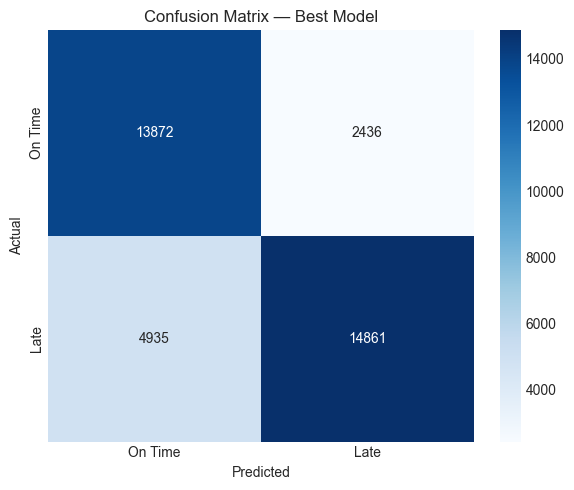


True Negatives (correctly predicted on-time): 13,872
False Positives (flagged late but was on-time): 2,436
False Negatives (missed — predicted on-time but was late): 4,935
True Positives (correctly caught late delivery): 14,861

False Negative Rate: 24.9% — these are the late deliveries we MISSED


In [5]:
plot_confusion_matrix(y_test, y_pred, title="Confusion Matrix — Best Model")

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives (correctly predicted on-time): {tn:,}")
print(f"False Positives (flagged late but was on-time): {fp:,}")
print(f"False Negatives (missed — predicted on-time but was late): {fn:,}")
print(f"True Positives (correctly caught late delivery): {tp:,}")
print(f"\nFalse Negative Rate: {fn/(fn+tp)*100:.1f}% — these are the late deliveries we MISSED")

## 6.5 ROC and Precision-Recall Curves

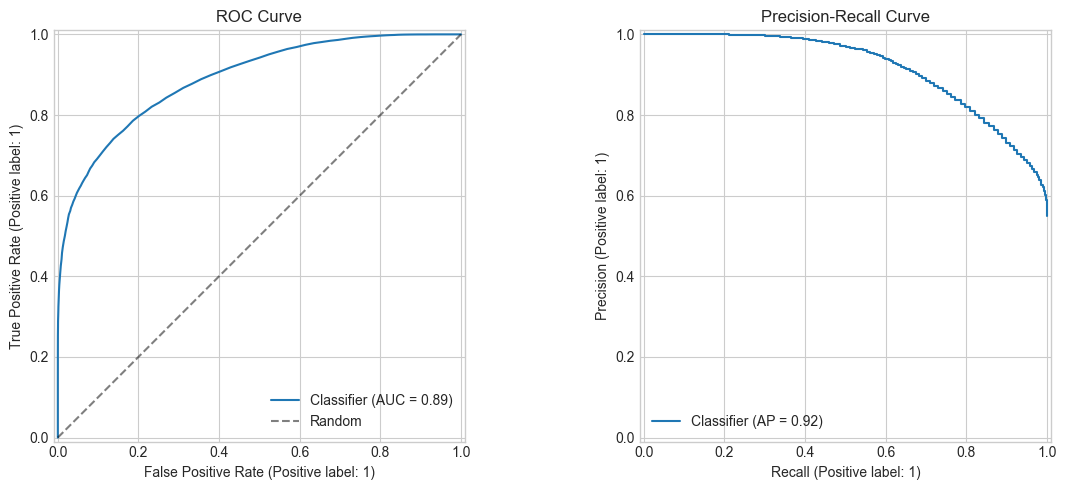

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0])
axes[0].set_title("ROC Curve")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

## 6.6 Threshold Analysis

The default threshold is 0.5, but that might not be optimal for every business context.

- **If we want to catch more late deliveries** (higher recall), we lower the threshold.
  Trade-off: more false alarms.
- **If we want fewer false alarms** (higher precision), we raise the threshold.
  Trade-off: we miss more actual late deliveries.

The right threshold depends on the cost of missing a late delivery vs the cost
of unnecessary intervention.

Metrics at Different Thresholds:
 Threshold  Precision   Recall       F1  Predicted_Positive_Rate
      0.30   0.672779 0.963730 0.792391                 0.785425
      0.35   0.712914 0.926652 0.805851                 0.712691
      0.40   0.762022 0.877349 0.815629                 0.631287
      0.45   0.810560 0.820469 0.815484                 0.555008
      0.50   0.850929 0.760962 0.803435                 0.490333
      0.55   0.885144 0.709689 0.787765                 0.439619
      0.60   0.909855 0.667408 0.769997                 0.402199
      0.65   0.927124 0.631087 0.750984                 0.373227
      0.70   0.942560 0.599313 0.732730                 0.348632


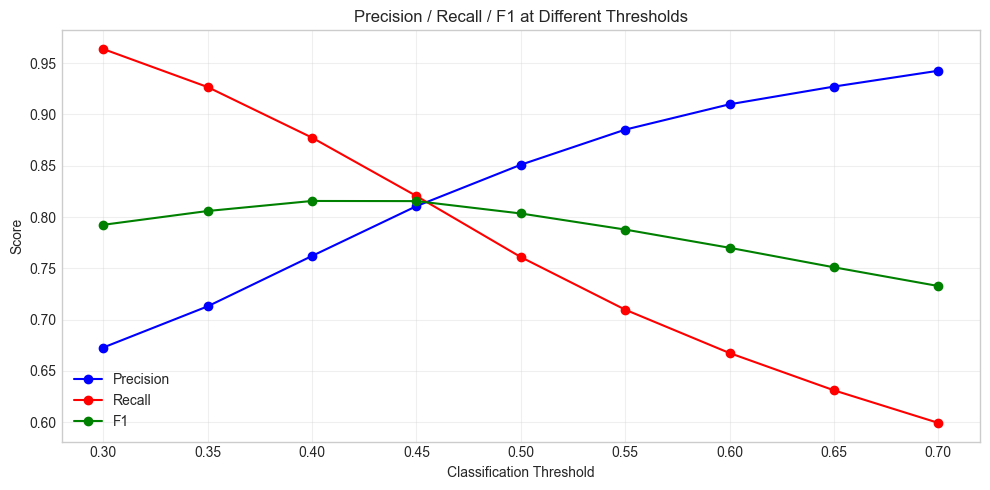

In [7]:
threshold_df = threshold_analysis(y_test, y_prob)
print("Metrics at Different Thresholds:")
print("=" * 70)
print(threshold_df.to_string(index=False))

# Plot threshold analysis
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(threshold_df["Threshold"], threshold_df["Precision"], "b-o", label="Precision")
ax.plot(threshold_df["Threshold"], threshold_df["Recall"], "r-o", label="Recall")
ax.plot(threshold_df["Threshold"], threshold_df["F1"], "g-o", label="F1")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 at Different Thresholds")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6.7 Probability-Based Risk Categories

Instead of binary predictions, we categorize orders into risk levels:

| Category | Probability Range | Interpretation |
|----------|------------------|----------------|
| **Low Risk** | < 0.3 | Model is fairly confident delivery will be on time |
| **Medium Risk** | 0.3 – 0.7 | Uncertain — could go either way |
| **High Risk** | ≥ 0.7 | Model is fairly confident delivery will be late |

**Note:** These thresholds are reasonable defaults, not optimized values.
The threshold analysis above can guide adjustments.

In [8]:
risk_categories = get_risk_category(y_prob)

risk_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted_prob": y_prob,
    "risk_category": risk_categories
})

print("Risk Category Distribution:")
print(risk_df["risk_category"].value_counts())
print()

# Late delivery rate within each risk category
print("Actual late delivery rate by risk category:")
for cat in ["Low Risk", "Medium Risk", "High Risk"]:
    subset = risk_df[risk_df["risk_category"] == cat]
    if len(subset) > 0:
        rate = subset["actual"].mean() * 100
        print(f"  {cat}: {rate:.1f}% actual late delivery rate (n={len(subset):,})")

Risk Category Distribution:
risk_category
Medium Risk    15770
High Risk      12587
Low Risk        7747
Name: count, dtype: int64

Actual late delivery rate by risk category:
  Low Risk: 9.3% actual late delivery rate (n=7,747)
  Medium Risk: 45.7% actual late delivery rate (n=15,770)
  High Risk: 94.3% actual late delivery rate (n=12,587)


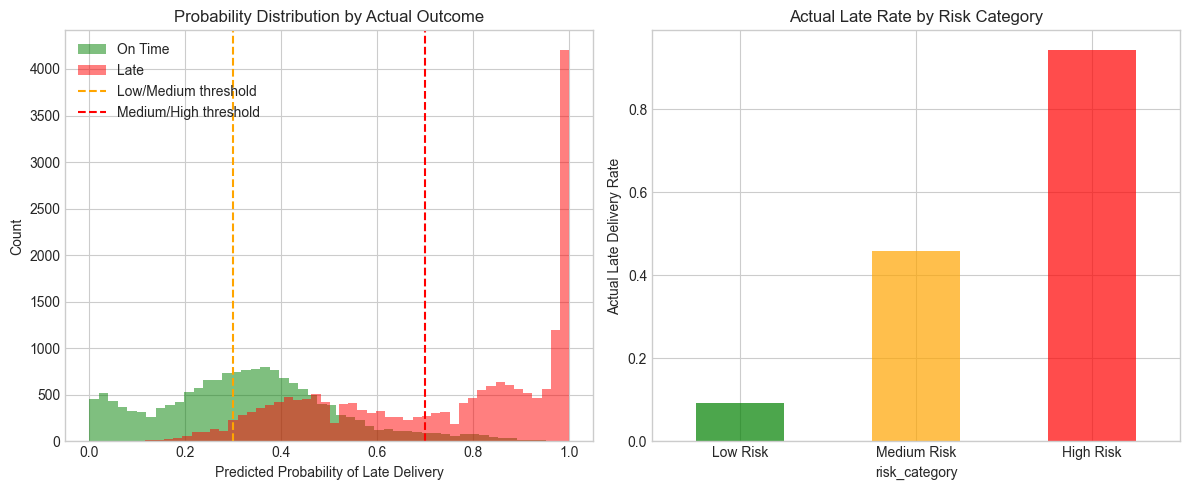

In [9]:
# Visualize risk distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Probability distribution
axes[0].hist(y_prob[y_test == 0], bins=50, alpha=0.5, label="On Time", color="green")
axes[0].hist(y_prob[y_test == 1], bins=50, alpha=0.5, label="Late", color="red")
axes[0].axvline(x=0.3, color="orange", linestyle="--", label="Low/Medium threshold")
axes[0].axvline(x=0.7, color="red", linestyle="--", label="Medium/High threshold")
axes[0].set_xlabel("Predicted Probability of Late Delivery")
axes[0].set_ylabel("Count")
axes[0].set_title("Probability Distribution by Actual Outcome")
axes[0].legend()

# Risk category bar
risk_counts = risk_df.groupby("risk_category")["actual"].agg(["count", "mean"])
risk_counts = risk_counts.reindex(["Low Risk", "Medium Risk", "High Risk"])
risk_counts["mean"].plot(kind="bar", ax=axes[1], color=["green", "orange", "red"], alpha=0.7)
axes[1].set_ylabel("Actual Late Delivery Rate")
axes[1].set_title("Actual Late Rate by Risk Category")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## Summary

**Key results:**
- The model achieves strong discriminative performance (see classification report above)
- Risk categories successfully stratify orders: High Risk orders have a much higher
  actual late delivery rate than Low Risk orders
- The threshold analysis shows the precision/recall trade-off at different cutoffs
- A threshold of 0.5 provides a reasonable balance, but operations teams can adjust
  based on their capacity for intervention

**Next step:** Error analysis — where does the model fail?